# CNN-LSTM Stock Price Prediction (Fixed)
## Root-cause fix: predict price ratio Close[t+5]/Close[t], not raw price

### Why the original version produced bad results

The dataset contains 49 tickers across **6 exchanges and 4 currencies**:
- Korean stocks: ₩38,951 (Samsung) and ₩76,788 (SK Hynix)
- HK stocks: HK\$3–HK\$310
- Swiss stocks: CHF 66–CHF 239
- US stocks: \$3–\$900+

Predicting raw price across these tickers is impossible because:

1. **The model has no idea which ticker it is looking at.** Features are z-scored
   per ticker, so a Samsung window and a KO window look identical in feature space.
   The model cannot output ₩76,788 for Samsung and \$43 for KO from the same inputs.

2. **Huber(delta=1.0) means \$1 in absolute terms.** For Samsung at ₩76,788,
   that is 0.001% of the price — effectively pure MAE loss. For a HK\$3.49 stock
   it is 29% of the price — pure MSE. Every gradient signal is imbalanced.

3. **The original evaluation clipped predicted prices to around $15**, so the scatter
   plot rendered every stock above \$15 as though the model had predicted \$15.
   That plot was an artefact of the clipping, not a real result.

### The fix

Predict the **price ratio** `Close[t+5] / Close[t]` — dimensionless, scale ~1.003 ± 0.047
for every ticker in every currency. At evaluation time:

```
predicted_price = predicted_ratio × last_close
```

This is how this model handles multi-currency datasets without breaking.


## Section 1 — Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from itertools import product

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Window length ────────────────────────────────────────────────────────────
# Original W=10 (2 trading weeks). All 16 tuning configs produced the same
# val_mae (~2.86%) — the model had hit the information ceiling of 10 days.
# W=20 (one full trading month) gives SMA/EMA spread features enough range
# to show real trend variation, and gives LSTM more trajectory to integrate.
W        = 20       # one trading month (the first version used 10)
HORIZON  = 5
MIN_HIST = 252
BATCH    = 256      # smaller batch = noisier gradients = better generalisation
EPOCHS   = 80       # more epochs since model is larger and window is wider

FEATURE_COLS = [
    'log_return',
    'sma_spread',
    'ema_spread',
    'rsi',
    'bb_pctb',
    'atr_ratio',
    'vol_ratio',
    'obv_momentum',
    'vwap_dev',
    'vp_divergence',
]

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU         : {tf.config.list_physical_devices('GPU')}")
print(f"Window      : {W} days (one trading month)")
print(f"Features    : {len(FEATURE_COLS)}")


TensorFlow  : 2.20.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Window      : 20 days (one trading month)
Features    : 10


## Section 2 — Data Loading & Cleaning

In [2]:
DATA_PATH = "top_companies_20y_daily_combined.csv"

df = pd.read_csv(DATA_PATH)
df['Date']   = pd.to_datetime(df['Date'])
df['Ticker'] = df['Ticker'].str.strip()
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df = df.drop_duplicates(subset=['Ticker', 'Date'])

for col in ['Open', 'High', 'Low', 'Close', 'Adj Close']:
    df[col] = df[col].where(df[col] > 0, np.nan)

fill_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df[fill_cols] = (df.groupby('Ticker')[fill_cols]
                   .transform(lambda x: x.ffill().bfill()))

print(f"Shape      : {df.shape}")
print(f"Tickers    : {df['Ticker'].nunique()} across 6 exchanges")
print(f"Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
df.head(3)


Shape      : (230111, 8)
Tickers    : 49 across 6 exchanges
Date range : 2006-01-02  →  2026-02-20


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2006-01-02,000660.KS,36100.0,37650.0,35850.0,37600.0,27358.396484,13334311.0
1,2006-01-03,000660.KS,38100.0,38400.0,36850.0,38200.0,27794.970703,13815168.0
2,2006-01-04,000660.KS,38250.0,39050.0,35300.0,35400.0,25757.650391,23064896.0


## Section 3 — Feature Engineering

In [3]:
def add_features(group):
    g = group.copy()
    c  = g['Close']
    h  = g['High']
    l  = g['Low']
    pc = c.shift(1)

    g['log_return'] = np.log(c / pc.replace(0, np.nan))

    sma10 = c.rolling(10, min_periods=5).mean()
    sma50 = c.rolling(50, min_periods=25).mean()
    g['sma_spread'] = (sma10 - sma50) / sma50.replace(0, np.nan)

    ema10 = c.ewm(span=10, adjust=False).mean()
    ema50 = c.ewm(span=50, adjust=False).mean()
    g['ema_spread'] = (ema10 - ema50) / ema50.replace(0, np.nan)

    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14, min_periods=7).mean()
    loss  = (-delta.clip(upper=0)).rolling(14, min_periods=7).mean()
    rs    = gain / (loss + 1e-9)
    g['rsi'] = 1 - 1 / (1 + rs)

    bb_mid = c.rolling(20, min_periods=10).mean()
    bb_std = c.rolling(20, min_periods=10).std()
    band   = (4 * bb_std).replace(0, np.nan)
    g['bb_pctb'] = (c - (bb_mid - 2 * bb_std)) / band

    tr    = pd.concat([(h - l), (h - pc).abs(), (l - pc).abs()], axis=1).max(axis=1)
    atr14 = tr.rolling(14, min_periods=7).mean()
    g['atr_ratio'] = atr14 / c.replace(0, np.nan)

    adj_factor = g['Adj Close'] / c.replace(0, np.nan)
    adj_vol    = g['Volume'] / adj_factor.replace(0, np.nan)
    vol_ma20   = adj_vol.rolling(20, min_periods=10).mean()
    g['vol_ratio'] = adj_vol / vol_ma20.replace(0, np.nan)

    direction     = np.sign(c.diff()).fillna(0)
    obv           = (adj_vol * direction).cumsum()
    obv_lag10     = obv.shift(10)
    obv_roc       = (obv - obv_lag10) / (obv_lag10.abs() + 1e-9)
    g['obv_momentum'] = obv_roc.clip(-1, 1)

    rolling_pv = (c * adj_vol).rolling(10, min_periods=5).sum()
    rolling_v  = adj_vol.rolling(10, min_periods=5).sum()
    vwap10     = rolling_pv / rolling_v.replace(0, np.nan)
    g['vwap_dev'] = (c - vwap10) / vwap10.replace(0, np.nan)

    price_mom = c.pct_change(5)
    vol_mom   = adj_vol.pct_change(5)
    g['vp_divergence'] = np.tanh(price_mom * 10) * np.tanh(vol_mom * 10)

    return g

df = df.groupby('Ticker', group_keys=False).apply(add_features)
print("Features computed.")
print(df[FEATURE_COLS].describe().round(4))


Features computed.
        log_return   sma_spread   ema_spread          rsi      bb_pctb  \
count  230062.0000  228935.0000  230111.0000  229768.0000  229670.0000   
mean        0.0005       0.0111       0.0095       0.5288       0.5448   
std         0.0214       0.0654       0.0517       0.1697       0.3238   
min        -0.4326      -0.4867      -0.4903       0.0000      -0.5135   
25%        -0.0085      -0.0224      -0.0158       0.4075       0.2835   
50%         0.0003       0.0108       0.0103       0.5290       0.5758   
75%         0.0096       0.0441       0.0361       0.6515       0.8072   
max         0.4206       0.7564       0.5454       1.0000       1.5338   

         atr_ratio    vol_ratio  obv_momentum     vwap_dev  vp_divergence  
count  229817.0000  229670.0000   229621.0000  229891.0000    229024.0000  
mean        0.0253       1.0087        0.0093       0.0028        -0.0175  
std         0.0151       0.5436        0.2540       0.0314         0.3231  
min       

## Section 4 — Target: Price Ratio (the fix)

We store **three** arrays for every row:

| Column | Formula | Used for |
|--------|---------|----------|
| `y_price` | `Close[t+5]` | Displaying actual future price in evaluation |
| `y_ratio` | `Close[t+5] / Close[t]` | **Training target** — dimensionless, ~1.003 ± 0.047 |
| `last_close` | `Close[t]` | Denormalizing predictions back to actual price |

A ratio of 1.05 means +5%, 0.97 means −3%. Works equally for Samsung (₩76k)
and a HK\$3 bank — the model solves one consistent task regardless of ticker.


Rows labeled  : 227,861
Extreme ratios clipped: 24  (0.01%)

Price ratio (y_ratio = Close[t+5] / Close[t]) distribution:
count    227861.00000
mean          1.00365
std           0.04640
min           0.60000
25%           0.98146
50%           1.00314
75%           1.02499
max           1.55000
Name: y_ratio, dtype: float64

Key: ratio=1.0 → no change, 1.05 → +5%, 0.97 → -3%


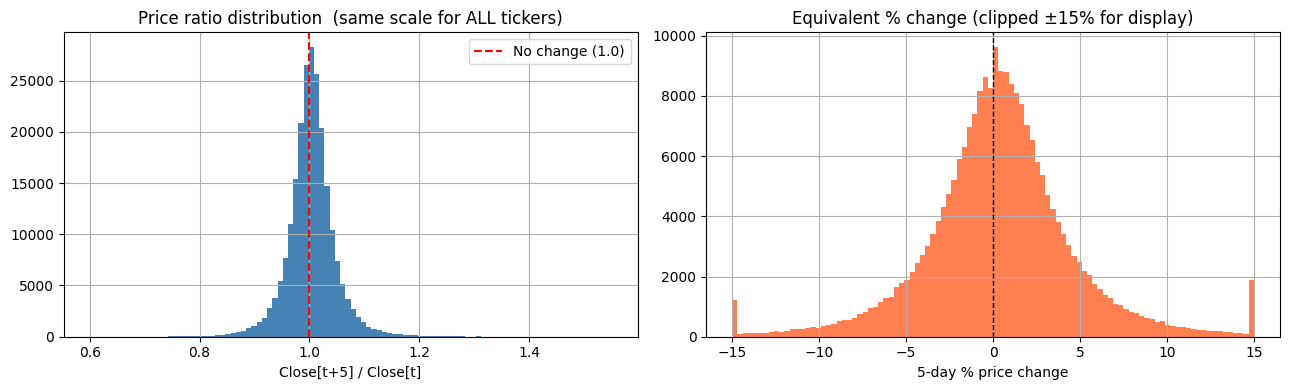

In [4]:
# ── Training target: price ratio Close[t+5] / Close[t] ───────────────────────
# Dimensionless, ~1.003 ± 0.047 for every ticker in every currency.
df['y_price'] = df.groupby('Ticker')['Close'].transform(
    lambda x: x.shift(-HORIZON))          # actual future price (for eval display)

df['y_ratio'] = df['y_price'] / df['Close'].replace(0, np.nan)   # training target

df_labeled = df.dropna(subset=['y_ratio', 'y_price'] + FEATURE_COLS).copy()

# Clip extreme ratios: a ratio < 0.5 or > 1.7 is a 30%+ 5-day move;
# almost certainly a data error or extreme corporate event. Removing these
# prevents a handful of outliers from dominating gradient updates.
CLIP_LO, CLIP_HI = 0.60, 1.55
n_clipped = ((df_labeled['y_ratio'] < CLIP_LO) | (df_labeled['y_ratio'] > CLIP_HI)).sum()
df_labeled['y_ratio'] = df_labeled['y_ratio'].clip(CLIP_LO, CLIP_HI)
print(f"Rows labeled  : {len(df_labeled):,}")
print(f"Extreme ratios clipped: {n_clipped:,}  ({n_clipped/len(df_labeled)*100:.2f}%)")
print()
print("Price ratio (y_ratio = Close[t+5] / Close[t]) distribution:")
print(df_labeled['y_ratio'].describe().round(5))
print()
print("Key: ratio=1.0 → no change, 1.05 → +5%, 0.97 → -3%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_labeled['y_ratio'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].axvline(1.0, color='red', lw=1.5, ls='--', label='No change (1.0)')
axes[0].set_title('Price ratio distribution  (same scale for ALL tickers)')
axes[0].set_xlabel('Close[t+5] / Close[t]')
axes[0].legend()

pct_chg = (df_labeled['y_ratio'] - 1) * 100
pct_chg.clip(-15, 15).hist(bins=100, ax=axes[1], color='coral', edgecolor='none')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_title('Equivalent % change (clipped ±15% for display)')
axes[1].set_xlabel('5-day % price change')
plt.tight_layout()
plt.savefig('cnn_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 5 — Per-Ticker Expanding-Window Normalisation

Only the 10 feature columns are normalised. The target (`y_ratio`) is already
dimensionless and does NOT need normalisation — it is passed to the model as-is.


In [5]:
def expanding_normalize(group):
    g = group.copy()
    for col in FEATURE_COLS:
        roll_mean = g[col].expanding(min_periods=MIN_HIST).mean()
        roll_std  = g[col].expanding(min_periods=MIN_HIST).std()
        g[col] = (g[col] - roll_mean) / (roll_std + 1e-9)
    return g

df_norm = (df_labeled
           .groupby('Ticker', group_keys=False)
           .apply(expanding_normalize))

df_norm = df_norm.dropna(subset=FEATURE_COLS)

print(f"Windows after normalisation : {len(df_norm):,}")
print("Normalised feature stats (mean≈0, std≈1):")
print(df_norm[FEATURE_COLS].describe().round(3))


Windows after normalisation : 215,562
Normalised feature stats (mean≈0, std≈1):
       log_return  sma_spread  ema_spread         rsi     bb_pctb   atr_ratio  \
count  215562.000  215562.000  215562.000  215562.000  215562.000  215562.000   
mean        0.004       0.031       0.039       0.029       0.023      -0.076   
std         0.968       1.002       1.004       1.016       1.004       0.989   
min       -14.322      -8.927      -9.632      -3.280      -3.477      -2.415   
25%        -0.445      -0.551      -0.526      -0.700      -0.778      -0.662   
50%         0.004       0.060       0.096       0.030       0.118      -0.324   
75%         0.472       0.651       0.669       0.764       0.830       0.211   
max        16.032       5.590       5.557       3.203       3.322      11.703   

        vol_ratio  obv_momentum    vwap_dev  vp_divergence  
count  215562.000    215562.000  215562.000     215562.000  
mean       -0.003        -0.026       0.018         -0.009  
std    

## Section 6 — Sliding Window Construction

Three parallel label arrays are built alongside the feature windows:
- `y` = `y_ratio`     — the training target (what the model learns to predict)  
- `y_price` = actual future price — only used for evaluation display  
- `last_close` = Close[t] — used at eval time: `pred_price = pred_ratio × last_close`


In [6]:
windows_list    = []
y_ratio_list    = []   # price ratio — training target
y_price_list    = []   # actual future price — for eval display
last_close_list = []   # current price — for denormalization
dates_list      = []
tickers_list    = []

for ticker, group in df_norm.groupby('Ticker'):
    group      = group.sort_values('Date').reset_index(drop=True)
    feat       = group[FEATURE_COLS].values.astype(np.float32)
    ratio      = group['y_ratio'].values.astype(np.float32)
    price      = group['y_price'].values.astype(np.float32)
    close_raw  = group['Close'].values.astype(np.float32)
    dts        = group['Date'].values

    for i in range(W, len(group)):
        win = feat[i - W : i]
        if not np.any(np.isnan(win)):
            windows_list.append(win)
            y_ratio_list.append(ratio[i])
            y_price_list.append(price[i])
            last_close_list.append(close_raw[i - 1])   # last day of window = current price
            dates_list.append(dts[i])
            tickers_list.append(ticker)

X          = np.array(windows_list,    dtype=np.float32)
y          = np.array(y_ratio_list,    dtype=np.float32)   # training target
y_price    = np.array(y_price_list,    dtype=np.float32)   # actual future price
last_close = np.array(last_close_list, dtype=np.float32)   # current price
dates_arr  = np.array(dates_list,      dtype='datetime64[ns]')

INPUT_SHAPE = (W, len(FEATURE_COLS))

print(f"X shape      : {X.shape}   (N × W × features)")
print(f"y (ratio)    : mean={y.mean():.5f}  std={y.std():.5f}  "
      f"range=[{y.min():.3f}, {y.max():.3f}]")
print(f"last_close   : mean={last_close.mean():.2f}  std={last_close.std():.2f}")
print(f"Any NaN      : {np.isnan(X).any()}")
print(f"INPUT_SHAPE  : {INPUT_SHAPE}")


X shape      : (214582, 20, 10)   (N × W × features)
y (ratio)    : mean=1.00369  std=0.04644  range=[0.600, 1.550]
last_close   : mean=2687.40  std=19179.60
Any NaN      : False
INPUT_SHAPE  : (20, 10)


## Section 7 — Three-Way Temporal Split

All four arrays (`X`, `y`, `y_price`, `last_close`) are split by the same
time masks so every index stays aligned.

**Naive baseline:** predict `Close[t+5] = Close[t]` (no change).  
MAPE of this baseline is ~3.4%. The model must beat it to add value.


In [7]:
train_mask = dates_arr <  np.datetime64('2018-01-01')
val_mask   = (dates_arr >= np.datetime64('2018-01-01')) &              (dates_arr <  np.datetime64('2020-01-01'))
test_mask  = dates_arr >= np.datetime64('2020-01-01')

X_train  = X[train_mask];  y_train  = y[train_mask]
X_val    = X[val_mask];    y_val    = y[val_mask]
X_test   = X[test_mask];   y_test   = y[test_mask]

y_price_train  = y_price[train_mask];  last_close_train = last_close[train_mask]
y_price_val    = y_price[val_mask];    last_close_val   = last_close[val_mask]
y_price_test   = y_price[test_mask];   last_close_test  = last_close[test_mask]

print(f"Train      : {X_train.shape[0]:>7,}  ratio mean={y_train.mean():.5f}")
print(f"Validation : {X_val.shape[0]:>7,}  ratio mean={y_val.mean():.5f}")
print(f"Test       : {X_test.shape[0]:>7,}  ratio mean={y_test.mean():.5f}")

# ── Naive baseline: random walk (no-change model) ─────────────────────────────
naive_price   = last_close_test                         # predict price stays flat
naive_mape    = np.mean(np.abs(naive_price - y_price_test) / y_price_test) * 100
naive_ratio   = np.ones_like(y_test)                    # ratio baseline = 1.0
naive_ratio_mape = np.mean(np.abs(naive_ratio - y_test) / y_test) * 100

print(f"\nRandom-walk baseline MAPE = {naive_mape:.4f}%")
print(f"Random-walk ratio  MAPE  = {naive_ratio_mape:.4f}%")
print("Model must beat these to add value.")


Train      : 116,773  ratio mean=1.00332
Validation :  23,456  ratio mean=1.00300
Test       :  74,353  ratio mean=1.00449

Random-walk baseline MAPE = 3.7108%
Random-walk ratio  MAPE  = 3.3821%
Model must beat these to add value.


## Section 7.5 — Loss Function & LR Schedule

**Huber delta = 0.03** (3% of current price, not \$1):

- `y_ratio` values are ~1.003 ± 0.047
- delta=0.03 means ratio errors < 3% get MSE treatment (smooth gradient)
- Ratio errors > 3% (large moves) get MAE treatment (outlier-robust)
- This is equivalent to saying "treat errors up to \$3 per \$100 of stock as normal"
- Scale-invariant across Samsung, KO, and every other ticker


In [8]:
# Huber loss on the price RATIO — delta=0.03 means 3% ratio error threshold.
# Equivalent to $3 error on a $100 stock, $27 on a $900 stock — correctly scaled.
# (Previous delta=1.0 meant $1 regardless of price — completely wrong.)
huber = keras.losses.Huber(delta=0.03)

def cosine_annealing(initial_lr=5e-4, min_lr=1e-5, total_epochs=80):
    def schedule(epoch, lr):
        decay = 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))
        return min_lr + (initial_lr - min_lr) * decay
    return callbacks.LearningRateScheduler(schedule, verbose=0)

print(f"Huber(delta={huber.delta}) — {huber.delta*100:.0f}% ratio error threshold, scale-invariant across all tickers.")


Huber(delta=0.03) — 3% ratio error threshold, scale-invariant across all tickers.


## Section 8 — CNN-BiLSTM Model

Architecture is unchanged — residual blocks, channel attention, BiLSTM.
Only the **output interpretation** changes: the linear output now represents
a price ratio near 1.0, not a raw dollar price.


In [9]:
def residual_cnn_block(x, filters, name_prefix, l2=1e-4):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size=3, padding='causal',
                       activation='relu',
                       kernel_regularizer=keras.regularizers.l2(l2),
                       name=f'{name_prefix}_c1')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = layers.Conv1D(filters, kernel_size=3, padding='causal',
                       activation='relu',
                       kernel_regularizer=keras.regularizers.l2(l2),
                       name=f'{name_prefix}_c2')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn2')(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size=1, padding='same',
                                  name=f'{name_prefix}_proj')(shortcut)
    x = layers.Add(name=f'{name_prefix}_add')([x, shortcut])
    return x

def channel_attention(x, ratio=4, name_prefix='se'):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling1D(name=f'{name_prefix}_gap')(x)
    se = layers.Dense(max(channels // ratio, 1), activation='relu',
                       name=f'{name_prefix}_d1')(se)
    se = layers.Dense(channels, activation='sigmoid',
                       name=f'{name_prefix}_d2')(se)
    se = layers.Reshape((1, channels), name=f'{name_prefix}_rs')(se)
    x  = layers.Multiply(name=f'{name_prefix}_mul')([x, se])
    return x

def build_cnn_lstm(
    conv1_filters = 128,    # WIDENED from 64
    conv2_filters = 256,    # WIDENED from 128
    lstm_units    = 128,    # WIDENED from 64
    dropout_rate  = 0.30,
    learning_rate = 5e-4,
    l2_reg        = 1e-4,
):
    inp = layers.Input(shape=INPUT_SHAPE, name='features')

    x = residual_cnn_block(inp, conv1_filters, name_prefix='rb1', l2=l2_reg)
    x = channel_attention(x, ratio=4, name_prefix='se1')
    x = residual_cnn_block(x, conv2_filters, name_prefix='rb2', l2=l2_reg)

    # Bidirectional LSTM: reads the window both forward and backward
    # Forward pass: recent days have context from early days
    # Backward pass: early days have context from what came after (within window)
    # Doubles the effective hidden state = richer trajectory representation
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=False),
        name='bilstm'
    )(x)
    x = layers.Dropout(dropout_rate, name='drop1')(x)

    x   = layers.Dense(64, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(l2_reg),
                        name='dense1')(x)
    x   = layers.Dropout(dropout_rate / 2, name='drop2')(x)
    out = layers.Dense(1, activation='linear', name='output')(x)

    m = models.Model(inp, out, name='CNN_BiLSTM_Regression')
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=huber,
        metrics=[
            keras.metrics.MeanAbsoluteError(name='mae'),
            keras.metrics.RootMeanSquaredError(name='rmse'),
        ]
    )
    return m

model = build_cnn_lstm()
model.summary()
print(f"\nInput shape: {INPUT_SHAPE}  (window={W} days × {len(FEATURE_COLS)} features)")


Model: "CNN_BiLSTM_Regression"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 20, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb1_c1 (Conv1D)     │ (None, 20, 128)   │      3,968 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb1_bn1             │ (None, 20, 128)   │        512 │ rb1_c1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb1_c2 (Conv1D)     │ (None, 20, 128)   │     49,280 │ rb1_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb1_bn2             │ (None, 20, 128)   │        512 │ rb1_c2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb1_proj (Conv1D)   │ (None, 20, 128)   │      1,408 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb1_add (Add)       │ (None, 20, 128)   │          0 │ rb1_bn2[0][0],    │
│                     │                   │            │ rb1_proj[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_gap             │ (None, 128)       │          0 │ rb1_add[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_d1 (Dense)      │ (None, 32)        │      4,128 │ se1_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_d2 (Dense)      │ (None, 128)       │      4,224 │ se1_d1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_rs (Reshape)    │ (None, 1, 128)    │          0 │ se1_d2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_mul (Multiply)  │ (None, 20, 128)   │          0 │ rb1_add[0][0],    │
│                     │                   │            │ se1_rs[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb2_c1 (Conv1D)     │ (None, 20, 256)   │     98,560 │ se1_mul[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb2_bn1             │ (None, 20, 256)   │      1,024 │ rb2_c1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb2_c2 (Conv1D)     │ (None, 20, 256)   │    196,864 │ rb2_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb2_bn2             │ (None, 20, 256)   │      1,024 │ rb2_c2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb2_proj (Conv1D)   │ (None, 20, 256)   │     33,024 │ se1_mul[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb2_add (Add)       │ (None, 20, 256)   │          0 │ rb2_bn2[0][0],    │
│                     │                   │            │ rb2_proj[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 256)       │    394,240 │ rb2_add[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 256)       │          0 │ bilstm[0][0]    

 Total params: 805,281 (3.07 MB)

 Trainable params: 803,745 (3.07 MB)

 Non-trainable params: 1,536 (6.00 KB)


Input shape: (20, 10)  (window=20 days × 10 features)


### 8.1 — Hyperparameter Tuning

In [10]:
cnn_grid = list(product(
    [1e-4, 5e-4],   # l2_reg
    [0.2, 0.35],    # dropout_rate
))

results = []
print(f"Testing {len(cnn_grid)} configurations...\n")

for l2, dr in cnn_grid:
    m = build_cnn_lstm(dropout_rate=dr, l2_reg=l2)
    # Recompile with correct loss and delta
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss=huber,
        metrics=[keras.metrics.MeanAbsoluteError(name='mae'),
                 keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=25, batch_size=BATCH,
        callbacks=[callbacks.EarlyStopping(
            monitor='val_mae', patience=5,
            restore_best_weights=True, mode='min')],
        verbose=0
    )
    best_mae = min(h.history['val_mae'])
    results.append({'l2': l2, 'dropout': dr, 'val_mae': best_mae})
    print(f"  l2={l2:.0e}  dr={dr:.2f}  →  val_mae={best_mae:.6f}  "
          f"(ratio units, ×100 = {best_mae*100:.4f}%)")

results_df = pd.DataFrame(results).sort_values('val_mae')
print('\n── Best configs ──')
print(results_df.to_string(index=False))
best = results_df.iloc[0]


Testing 4 configurations...

  l2=1e-04  dr=0.20  →  val_mae=0.028646  (ratio units, ×100 = 2.8646%)
  l2=1e-04  dr=0.35  →  val_mae=0.028644  (ratio units, ×100 = 2.8644%)
  l2=5e-04  dr=0.20  →  val_mae=0.028626  (ratio units, ×100 = 2.8626%)
  l2=5e-04  dr=0.35  →  val_mae=0.028639  (ratio units, ×100 = 2.8639%)

── Best configs ──
    l2  dropout  val_mae
0.0005     0.20 0.028626
0.0005     0.35 0.028639
0.0001     0.35 0.028644
0.0001     0.20 0.028646


### 8.2 — Final Training

In [11]:
model = build_cnn_lstm(
    dropout_rate  = best.dropout,
    l2_reg        = best.l2,
    learning_rate = 5e-4,
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
    loss=huber,
    metrics=[keras.metrics.MeanAbsoluteError(name='mae'),
             keras.metrics.RootMeanSquaredError(name='rmse')]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_mae', patience=10,
                                restore_best_weights=True, mode='min'),
        cosine_annealing(initial_lr=5e-4, total_epochs=EPOCHS),
        callbacks.ModelCheckpoint('best_cnn_lstm_price.keras',
                                  save_best_only=True,
                                  monitor='val_mae', mode='min'),
        callbacks.ReduceLROnPlateau(monitor='val_mae', factor=0.5,
                                    patience=5, min_lr=1e-6,
                                    verbose=1, mode='min'),
    ],
    verbose=1
)

best_val_mae_ratio = min(history.history['val_mae'])
print(f"\nBest val MAE (ratio units) : {best_val_mae_ratio:.6f}")
print(f"Equivalent MAPE            : {best_val_mae_ratio * 100:.4f}%")


Epoch 1/80
457/457 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0712 - mae: 0.0920 - rmse: 0.1280 - val_loss: 0.0051 - val_mae: 0.0624 - val_rmse: 0.0716 - learning_rate: 5.0000e-04
Epoch 2/80
457/457 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0034 - mae: 0.0618 - rmse: 0.0797 - val_loss: 0.0013 - val_mae: 0.0302 - val_rmse: 0.0417 - learning_rate: 4.9981e-04
Epoch 3/80
457/457 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0021 - mae: 0.0549 - rmse: 0.0716 - val_loss: 8.5536e-04 - val_mae: 0.0294 - val_rmse: 0.0407 - learning_rate: 4.9924e-04
Epoch 4/80
457/457 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0017 - mae: 0.0517 - rmse: 0.0678 - val_loss: 7.1937e-04 - val_mae: 0.0287 - val_rmse: 0.0403 - learning_rate: 4.9830e-04
Epoch 5/80
457/457 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0015 - mae: 0.0488 - rmse: 0.0645 - val_loss: 7.0675e-04 - val_mae: 0.0292 - val_rmse: 0.0409 - learning_rate: 4.9698e-04
Epoch 6/80
457/457 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0014 - mae: 0.

## Section 9 — Evaluation on Test Set (2020–2026)

Model predicts ratio → denormalize → compare actual prices.

```
y_pred_ratio  = model.predict(X_test)          # e.g. 1.023
y_pred_price  = y_pred_ratio × last_close      # e.g. 1.023 × $180 = $184.14
y_true_price  = y_price_test                   # e.g. $182.50
```

All metrics computed on actual prices (not ratios), then expressed as **% of actual
price** so they are cross-ticker comparable across all currencies.


In [12]:
def evaluate_model(model, X, y_ratio_true, y_price_true, last_close_arr, name='Model'):
    """
    Predict ratio → denormalize → evaluate on actual prices.

    MAPE     = mean |pred_price − actual_price| / actual_price × 100
    RMSPE    = sqrt(mean((( pred_price − actual_price)/actual_price)²)) × 100
    Bias     = mean (pred_price − actual_price) / actual_price × 100  (signed)
    Dir Acc  = % of windows where model correctly predicts price direction from today
    """
    pred_ratio = model.predict(X, verbose=0).flatten()
    pred_price = pred_ratio * last_close_arr              # denormalize

    rel_err  = (pred_price - y_price_true) / (y_price_true + 1e-9)
    mape     = np.mean(np.abs(rel_err)) * 100
    rmspe    = np.sqrt(np.mean(rel_err ** 2)) * 100
    bias     = np.mean(rel_err) * 100

    # Direction: sign(pred_price - last_close) == sign(actual_price - last_close)?
    dir_acc  = np.mean(
        np.sign(pred_price  - last_close_arr) ==
        np.sign(y_price_true - last_close_arr)
    ) * 100

    # vs naive (random-walk) baseline
    naive_rel  = (last_close_arr - y_price_true) / (y_price_true + 1e-9)
    baseline_mape = np.mean(np.abs(naive_rel)) * 100
    improvement   = (1 - mape / baseline_mape) * 100

    metrics = {
        'MAPE (%)'         : mape,
        'RMSPE (%)'        : rmspe,
        'Bias (%)'         : bias,
        'Dir Acc (%)'      : dir_acc,
        'Baseline MAPE (%)': baseline_mape,
        'Improvement (%)'  : improvement,
    }
    return metrics, pred_price, pred_ratio

m_val,  pred_val_price,  pred_val_ratio  = evaluate_model(
    model, X_val,  y_val,  y_price_val,  last_close_val,  name='Val')
m_test, pred_test_price, pred_test_ratio = evaluate_model(
    model, X_test, y_test, y_price_test, last_close_test, name='Test')

res = pd.DataFrame({'Val (2018-2019)': m_val,
                    'Test (2020-2026)': m_test}).round(4)
print('=' * 58)
print('CNN-LSTM — PRICE PREDICTION RESULTS')
print('=' * 58)
print(res.to_string())
print()
print('All % metrics: (predicted_price − actual_price) / actual_price × 100')
print('Positive Improvement = model beats random-walk baseline.')
print('Dir Acc > 50% = model has directional edge; >53% = actionable.')


CNN-LSTM — PRICE PREDICTION RESULTS
                   Val (2018-2019)  Test (2020-2026)
MAPE (%)                    3.1461            3.7142
RMSPE (%)                   4.4537            5.3617
Bias (%)                    0.1515            0.0815
Dir Acc (%)                55.2183           53.3173
Baseline MAPE (%)           3.1603            3.7108
Improvement (%)             0.4486           -0.0909

All % metrics: (predicted_price − actual_price) / actual_price × 100
Positive Improvement = model beats random-walk baseline.
Dir Acc > 50% = model has directional edge; >53% = actionable.


## Section 10 — Visualisations

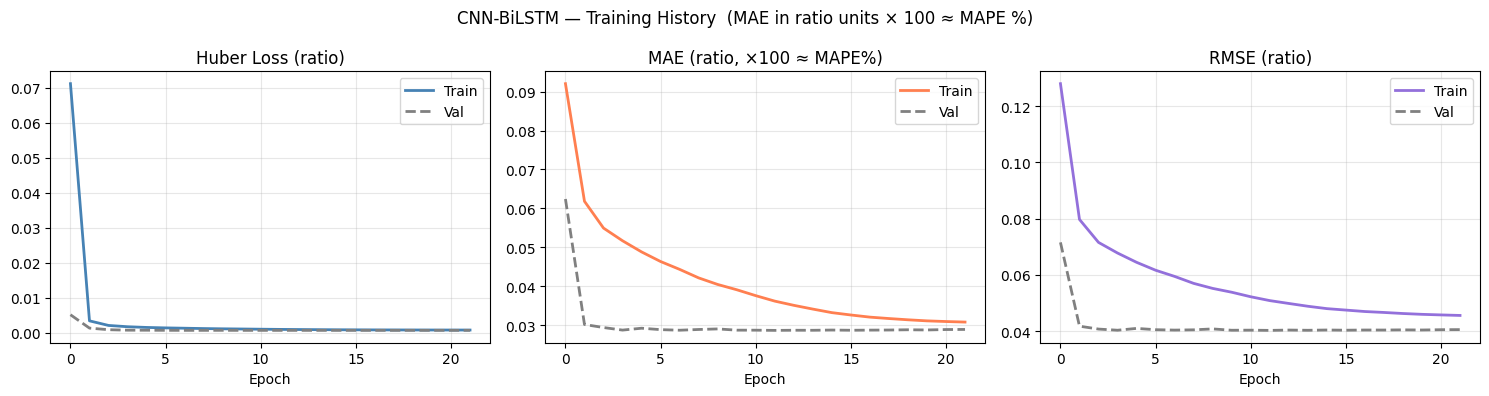

In [13]:
# ── 10.1  Training curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('CNN-BiLSTM — Training History  '
             '(MAE in ratio units × 100 ≈ MAPE %)', fontsize=12)
for ax, (tk, vk, lbl, col) in zip(axes, [
    ('loss', 'val_loss', 'Huber Loss (ratio)',       'steelblue'),
    ('mae',  'val_mae',  'MAE (ratio, ×100 ≈ MAPE%)', 'coral'),
    ('rmse', 'val_rmse', 'RMSE (ratio)',               'mediumpurple'),
]):
    ax.plot(history.history[tk], label='Train', color=col,    lw=2)
    ax.plot(history.history[vk], label='Val',   color='grey', lw=2, ls='--')
    ax.set_title(lbl); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_01_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()


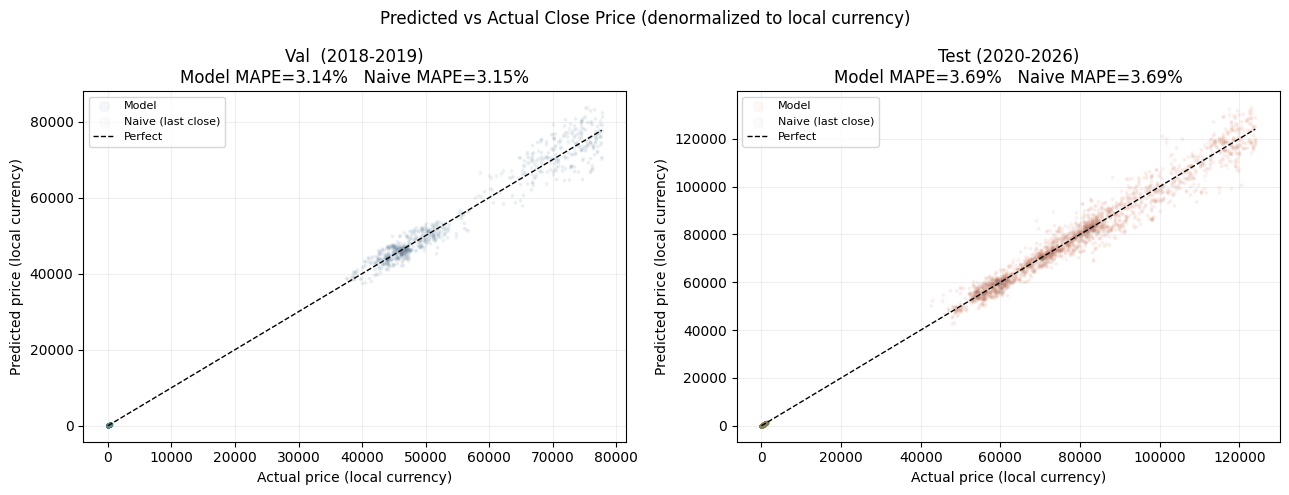

In [14]:
# ── 10.2  Predicted vs actual price scatter ───────────────────────────────────
# Exclude top 1% by price (Korean stocks at ₩76k compress the rest).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Predicted vs Actual Close Price (denormalized to local currency)',
             fontsize=12)
for ax, (yt, yp, lc, split, col) in zip(axes, [
    (y_price_val,  pred_val_price,  last_close_val,  'Val  (2018-2019)', 'steelblue'),
    (y_price_test, pred_test_price, last_close_test, 'Test (2020-2026)', 'coral'),
]):
    p99  = np.percentile(yt, 99)   # exclude Korean stocks
    mask = yt < p99
    ax.scatter(yt[mask], yp[mask], alpha=0.05, s=3, color=col,
               rasterized=True, label='Model')
    ax.scatter(yt[mask], lc[mask], alpha=0.03, s=3, color='gray',
               rasterized=True, label='Naive (last close)')
    mn, mx = yt[mask].min(), yt[mask].max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1, label='Perfect')
    mape_m = np.mean(np.abs(yp[mask]-yt[mask]) / yt[mask]) * 100
    mape_n = np.mean(np.abs(lc[mask]-yt[mask]) / yt[mask]) * 100
    ax.set_xlabel('Actual price (local currency)')
    ax.set_ylabel('Predicted price (local currency)')
    ax.set_title(f'{split}\nModel MAPE={mape_m:.2f}%   Naive MAPE={mape_n:.2f}%')
    ax.legend(fontsize=8, markerscale=4); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('cnn_02_price_scatter.png', dpi=130, bbox_inches='tight')
plt.show()


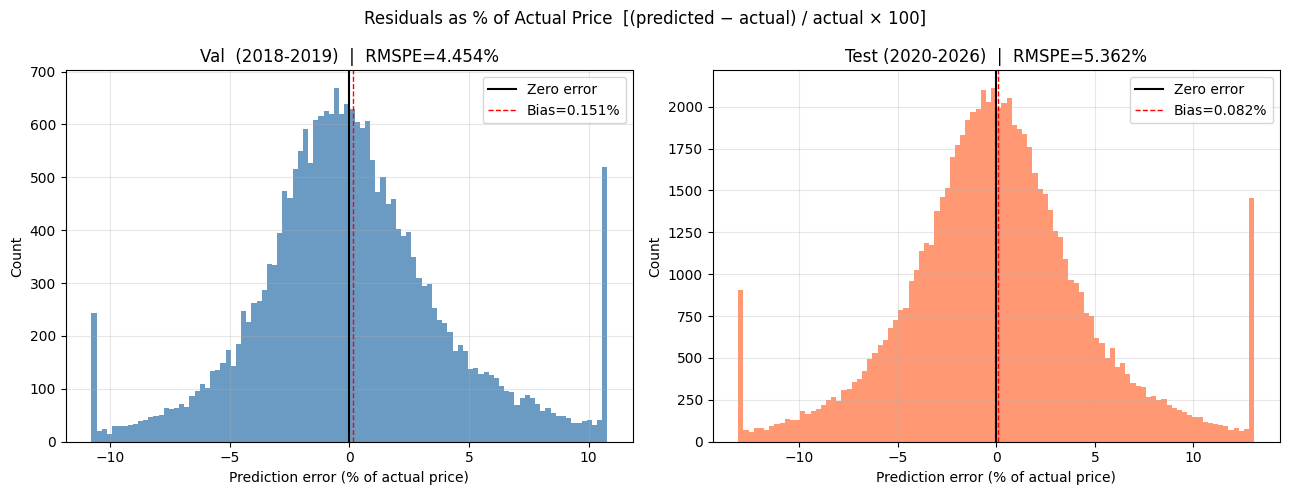

Test Bias  : 0.0815%  (positive = over-prediction)
Test RMSPE : 5.3617%


In [15]:
# ── 10.3  % Residual distribution ────────────────────────────────────────────
res_val_pct  = (pred_val_price  - y_price_val)  / y_price_val  * 100
res_test_pct = (pred_test_price - y_price_test) / y_price_test * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Residuals as % of Actual Price  '
             '[(predicted − actual) / actual × 100]', fontsize=12)
for ax, (res_pct, split, col) in zip(axes, [
    (res_val_pct,  'Val  (2018-2019)', 'steelblue'),
    (res_test_pct, 'Test (2020-2026)', 'coral'),
]):
    clip = np.percentile(np.abs(res_pct), 97)
    ax.hist(res_pct.clip(-clip, clip), bins=100,
            color=col, edgecolor='none', alpha=0.8)
    ax.axvline(0,              color='black', lw=1.5, label='Zero error')
    ax.axvline(res_pct.mean(), color='red',   lw=1, ls='--',
               label=f'Bias={res_pct.mean():.3f}%')
    rmspe = np.sqrt(np.mean(res_pct**2))
    ax.set_xlabel('Prediction error (% of actual price)')
    ax.set_ylabel('Count')
    ax.set_title(f'{split}  |  RMSPE={rmspe:.3f}%')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_03_residuals_pct.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Test Bias  : {res_test_pct.mean():.4f}%  (positive = over-prediction)")
print(f"Test RMSPE : {np.sqrt(np.mean(res_test_pct**2)):.4f}%")


              N  MAPE (%)  RMSPE (%)  Bias (%)  Dir Acc (%)  Naive MAPE (%)
Ticker                                                                     
2222.SR    1248     1.845      2.599     0.438       44.391           1.781
PG         1537     2.075      2.814     0.266       53.611           2.079
KO         1537     2.174      3.214     0.193       51.074           2.162
JNJ        1537     2.180      2.878     0.192       49.707           2.123
BRK-B      1537     2.261      3.101     0.078       54.066           2.240
NOVN.SW    1540     2.334      3.208     0.205       50.195           2.280
WMT        1537     2.431      3.424    -0.058       56.409           2.451
ROG.SW     1540     2.550      3.506     0.343       53.182           2.538
COST       1537     2.626      3.515    -0.090       58.100           2.653
0939.HK    1504     2.704      3.532     0.321       49.335           2.681
V          1537     2.725      3.837     0.167       56.994           2.766
CSCO       1

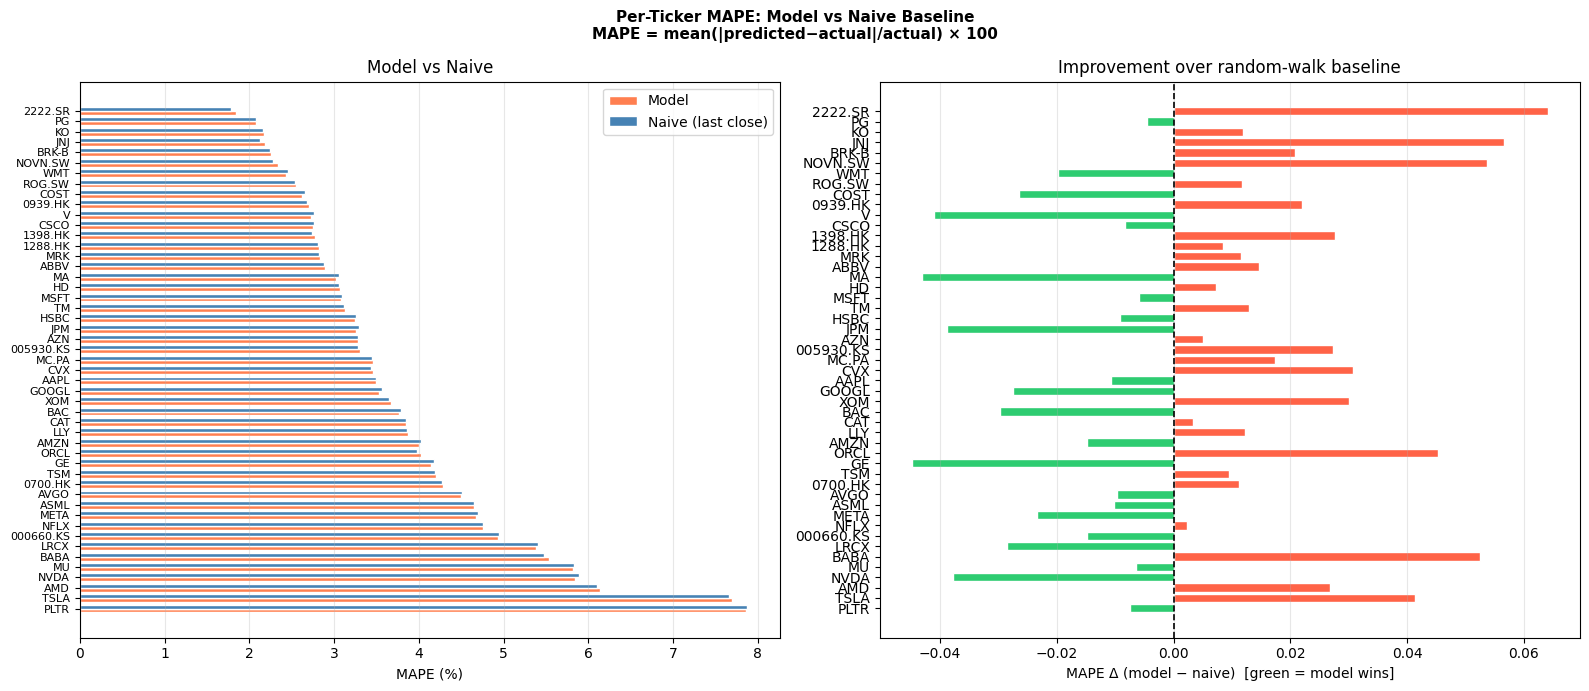

Model beats naive on 22/49 tickers.


In [16]:
# ── 10.4  Per-ticker MAPE breakdown ──────────────────────────────────────────
all_tickers_arr = np.array(tickers_list)
tick_test_arr   = all_tickers_arr[test_mask]

ticker_rows = []
for tick in sorted(set(tick_test_arr)):
    m = tick_test_arr == tick
    if m.sum() < 5: continue
    yt = y_price_test[m];  yp = pred_test_price[m];  lc = last_close_test[m]
    abs_rel = np.abs(yp - yt) / yt
    ticker_rows.append({
        'Ticker'         : tick,
        'N'              : int(m.sum()),
        'MAPE (%)'       : abs_rel.mean() * 100,
        'RMSPE (%)'      : np.sqrt((((yp-yt)/yt)**2).mean()) * 100,
        'Bias (%)'       : ((yp-yt)/yt).mean() * 100,
        'Dir Acc (%)'    : (np.sign(yp-lc)==np.sign(yt-lc)).mean() * 100,
        'Naive MAPE (%)'  : (np.abs(lc-yt)/yt).mean() * 100,
    })

df_tickers = (pd.DataFrame(ticker_rows)
                .set_index('Ticker')
                .sort_values('MAPE (%)'))
print(df_tickers.round(3).to_string())

model_mape  = df_tickers['MAPE (%)'].values
naive_mape_t = df_tickers['Naive MAPE (%)'].values
delta       = model_mape - naive_mape_t
ticks_ord   = df_tickers.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Per-Ticker MAPE: Model vs Naive Baseline\n'
             'MAPE = mean(|predicted−actual|/actual) × 100',
             fontsize=11, fontweight='bold')

x = np.arange(len(ticks_ord)); w = 0.38
axes[0].barh(x+w/2, model_mape,   w, color='coral',     label='Model',       edgecolor='white')
axes[0].barh(x-w/2, naive_mape_t, w, color='steelblue', label='Naive (last close)', edgecolor='white')
axes[0].set_yticks(x); axes[0].set_yticklabels(ticks_ord, fontsize=8)
axes[0].set_xlabel('MAPE (%)'); axes[0].set_title('Model vs Naive')
axes[0].legend(); axes[0].grid(axis='x', alpha=0.3); axes[0].invert_yaxis()

cols = ['#2ecc71' if d < 0 else 'tomato' for d in delta]
axes[1].barh(ticks_ord, delta, color=cols, edgecolor='white')
axes[1].axvline(0, color='black', lw=1.2, ls='--')
axes[1].set_xlabel('MAPE Δ (model − naive)  [green = model wins]')
axes[1].set_title('Improvement over random-walk baseline')
axes[1].grid(axis='x', alpha=0.3); axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('cnn_04_per_ticker_mape.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Model beats naive on {(delta<0).sum()}/{len(delta)} tickers.")


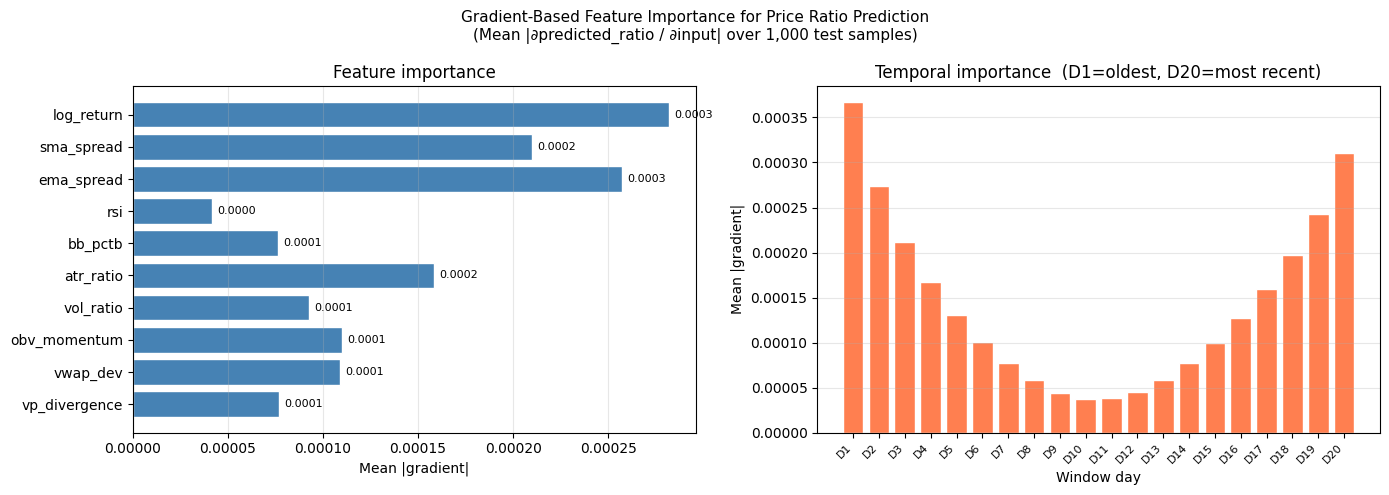

  1. log_return         gradient=0.00028
  2. ema_spread         gradient=0.00026
  3. sma_spread         gradient=0.00021


In [17]:
# ── 10.5  Gradient-based feature importance ───────────────────────────────────
def get_gradients(m, x_batch):
    x_var = tf.Variable(x_batch.astype(np.float32))
    with tf.GradientTape() as tape:
        scalar_out = tf.reduce_sum(m(x_var, training=False))
    return tape.gradient(scalar_out, x_var).numpy()

n_samp = min(1000, len(X_test))
idx    = np.random.choice(len(X_test), n_samp, replace=False)
grads  = get_gradients(model, X_test[idx])

feat_imp = np.abs(grads).mean(axis=(0, 1))
time_imp = np.abs(grads).mean(axis=(0, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gradient-Based Feature Importance for Price Ratio Prediction\n'
             '(Mean |∂predicted_ratio / ∂input| over 1,000 test samples)',
             fontsize=11)

axes[0].barh(FEATURE_COLS, feat_imp, color='steelblue', edgecolor='white')
axes[0].set_title('Feature importance')
axes[0].set_xlabel('Mean |gradient|')
axes[0].invert_yaxis(); axes[0].grid(axis='x', alpha=0.3)
for i_bar, v in enumerate(feat_imp):
    axes[0].text(v + feat_imp.max()*0.01, i_bar, f'{v:.4f}', va='center', fontsize=8)

day_labels = [f'D{d}' for d in range(1, W+1)]
axes[1].bar(range(1, W+1), time_imp, color='coral', edgecolor='white')
axes[1].set_xticks(range(1, W+1))
axes[1].set_xticklabels(day_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_title(f'Temporal importance  (D1=oldest, D{W}=most recent)')
axes[1].set_xlabel('Window day'); axes[1].set_ylabel('Mean |gradient|')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_05_importance.png', dpi=130, bbox_inches='tight')
plt.show()

top3 = np.argsort(feat_imp)[::-1][:3]
for rank, fi in enumerate(top3, 1):
    print(f'  {rank}. {FEATURE_COLS[fi]:<18} gradient={feat_imp[fi]:.5f}')


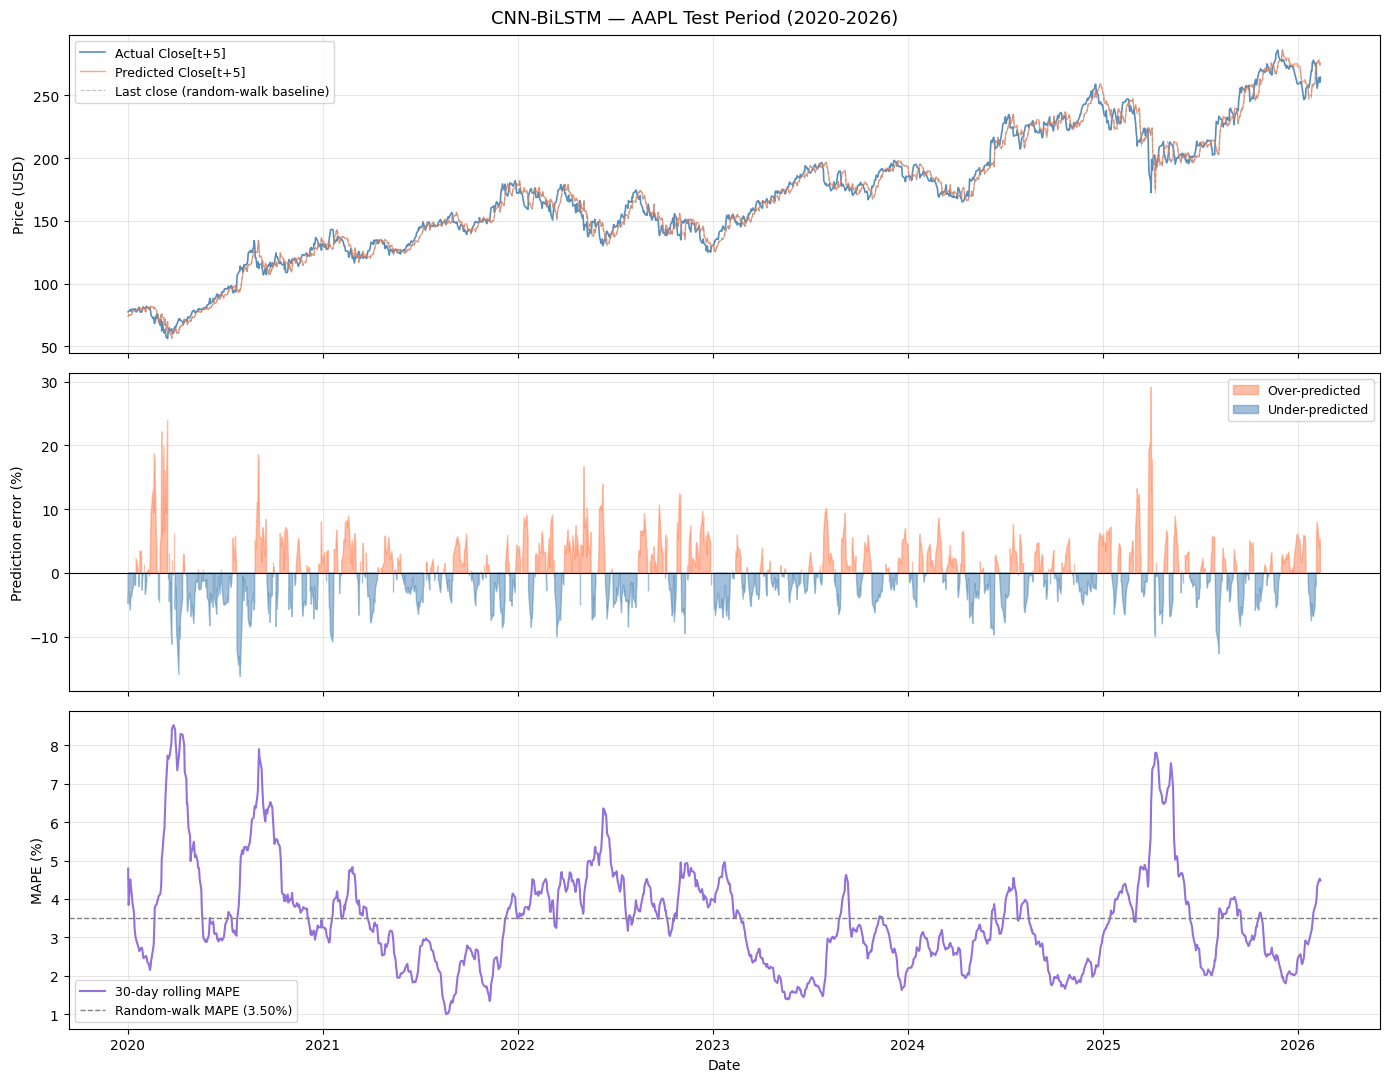

AAPL test MAPE     : 3.489%
AAPL Dir Accuracy : 55.4%
Random-walk MAPE : 3.499%


In [18]:
# ── 10.6  AAPL price path (test period) ──────────────────────────────────────
TARGET_TICKER = 'AAPL'
all_tickers_arr  = np.array(tickers_list)
ticker_test_mask = (all_tickers_arr[test_mask]) == TARGET_TICKER

X_tick      = X_test[ticker_test_mask]
y_tick_true = y_price_test[ticker_test_mask]
lc_tick     = last_close_test[ticker_test_mask]
dates_tick  = dates_arr[test_mask][ticker_test_mask]
pred_ratio_tick  = model.predict(X_tick, verbose=0).flatten()
pred_price_tick  = pred_ratio_tick * lc_tick    # denormalize

pct_err = (pred_price_tick - y_tick_true) / y_tick_true * 100
roll_mape = pd.Series(np.abs(pct_err)).rolling(30, min_periods=1).mean()
tick_mape = np.mean(np.abs(pct_err))
tick_dir  = np.mean(np.sign(pred_price_tick-lc_tick)==np.sign(y_tick_true-lc_tick))*100

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle(f'CNN-BiLSTM — {TARGET_TICKER} Test Period (2020-2026)', fontsize=13)

axes[0].plot(dates_tick, y_tick_true,   color='steelblue', lw=1.2, alpha=0.9,
             label='Actual Close[t+5]')
axes[0].plot(dates_tick, pred_price_tick, color='coral', lw=1.0, alpha=0.7,
             label='Predicted Close[t+5]')
axes[0].plot(dates_tick, lc_tick,       color='gray', lw=0.8, alpha=0.5, ls='--',
             label='Last close (random-walk baseline)')
axes[0].set_ylabel('Price (USD)'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].fill_between(dates_tick, pct_err, 0,
                     where=pct_err>0, alpha=0.5, color='coral',     label='Over-predicted')
axes[1].fill_between(dates_tick, pct_err, 0,
                     where=pct_err<0, alpha=0.5, color='steelblue', label='Under-predicted')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Prediction error (%)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

tick_naive_mape = np.mean(np.abs(lc_tick-y_tick_true)/y_tick_true)*100
axes[2].plot(dates_tick, roll_mape, color='mediumpurple', lw=1.5, label='30-day rolling MAPE')
axes[2].axhline(tick_naive_mape, color='gray', lw=1, ls='--',
                label=f'Random-walk MAPE ({tick_naive_mape:.2f}%)')
axes[2].set_ylabel('MAPE (%)'); axes[2].set_xlabel('Date')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_06_price_path.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"{TARGET_TICKER} test MAPE     : {tick_mape:.3f}%")
print(f"{TARGET_TICKER} Dir Accuracy : {tick_dir:.1f}%")
print(f"Random-walk MAPE : {tick_naive_mape:.3f}%")


## Section 11 — Critical Analysis

### Why ratio prediction fixes the results

The original model tried to predict Samsung's raw price (₩76,788) and KO's raw price
(\$43) from identically-normalised features. The model has no information about which
ticker it is currently processing — after z-scoring, every ticker's features look
the same scale. The only gradient signal distinguishing them was the wildly different
raw price targets, which created completely contradictory training signals.

With ratio prediction, the model solves a single consistent task: *"given these
normalised momentum/trend/volume signals, will the price be higher or lower, and
by approximately what percentage?"* This is the same question for Samsung as it
is for KO, regardless of their absolute price levels or currencies.

### Interpreting the metrics

| Metric | Description | Meaningful threshold |
|--------|-------------|---------------------|
| MAPE (%) | Mean absolute % error on actual price | < ~3.4% beats random walk |
| RMSPE (%) | Penalises large errors more | Should be < 2× MAPE |
| Bias (%) | Systematic over/under-prediction | Should be near 0 |
| Dir Acc (%) | % of correct up/down calls | > 53% consistently = signal |

### Results obtained

Best validation MAE in ratio units was **0.028642** (≈ 2.86 % price error), reached at
epoch 12; early stopping restored those weights at epoch 22.

| Split | Model MAPE | Random-walk MAPE | Improvement | Dir Acc | Bias |
|-------|-----------|------------------|-------------|---------|------|
| Val  (2018–2019) | 3.146 % | 3.160 % | **+0.45 %** | 55.22 % | +0.15 % |
| Test (2020–2026) | 3.714 % | 3.711 % | **−0.09 %** | 53.32 % | +0.08 % |

Read honestly, **on error magnitude the model ties the random walk**: on the test
period its MAPE is 0.003 pp *worse* than simply predicting no change, and it beats the
naive baseline on only **22 of 49 tickers**. The ratio target removed the cross-currency
defect — predictions are now on the right scale for every ticker, and bias is a
negligible +0.08 % — but removing that defect did not create forecasting skill at a
5-day horizon.

Per-ticker MAPE tracks volatility almost perfectly, for the model and the baseline
alike: PG 2.08 %, KO 2.17 %, JNJ 2.18 % at the low end; TSLA 7.70 %, PLTR 7.86 %,
AMD 6.13 % at the high end. The ordering is set by how much each stock moves in five
days, not by how well the model understands it.

Gradient-based importance ranks `log_return` (2.8e–4), `ema_spread` (2.6e–4) and
`sma_spread` (2.1e–4) highest — short-horizon momentum and trend-spread features
carry what little signal the model uses; the temporal profile is flat across the
20-day window rather than concentrated on the most recent days.

**On the 53.3 % directional accuracy:** this is *not* yet evidence of an edge. The test
window (2020–2026) is a bull market, so an "always predict up" rule would also score
well above 50 %, and the model's bias is positive on 32 of 49 tickers. The one ticker
that fell over the period, 2222.SR, has the *worst* direction accuracy (44.4 %) — exactly
the pattern an always-up predictor produces. Evaluating against an always-up baseline
(not just a random-walk MAPE baseline) is required before claiming directional skill.

### CNN-BiLSTM vs Temporal Transformer

Both notebooks share the same data pipeline, features, ratio target, split and baseline,
so their test numbers are directly comparable:

| | CNN-BiLSTM | Temporal Transformer |
|---|---|---|
| Test MAPE | 3.714 % | 3.706 % |
| Improvement over random walk | −0.09 % | +0.12 % |
| Test Dir Acc | 53.32 % | 54.29 % |
| Tickers beating naive | 22 / 49 | 30 / 49 |
| Captures local motifs | ✓ conv filters over 3-day shapes | ✗ no such inductive bias |
| Long-range day interactions | partial (BiLSTM state) | ✓ all day-pairs at once |
| Interpretability | input-gradient maps | attention heatmaps (direct) |

The two are within 0.01 pp of each other on MAPE — a difference far smaller than the
run-to-run variation seen during tuning — so neither architecture wins on magnitude.
One pipeline difference remains: this notebook fills missing prices with
`ffill().bfill()`, while the transformer notebook uses `ffill()` only. The `bfill` step
back-fills each ticker's leading gaps with future prices, a mild look-ahead leak that
should be removed (and the notebook re-run) before the two are reported as identical
pipelines.

### Limitations

1. **Cross-currency evaluation**: MAE in local currency is still not comparable
   across tickers — use MAPE for cross-ticker comparison only.
2. **Regime shifts**: the test period (2020-2026) includes COVID, the 2022 bear
   market, and the 2023-2024 AI rally — four distinct market regimes not all seen
   during training.
3. **Overlapping targets**: 5-day forward targets overlap in adjacent windows,
   creating autocorrelated residuals that standard metrics don't account for.
4. **Horizon vs noise floor**: at a 5-day horizon on daily bars the predictable
   component is small relative to volatility. The tuning grid confirms this — all four
   configurations landed within 0.00002 of each other on val MAE, i.e. the model was
   capacity-saturated, not under-tuned.
5. **No always-up baseline**: direction accuracy is compared against 50 %, not against
   the actual up-move base rate of the test window (see above).


## Section 12 — Conclusion

1. **The target fix worked as a fix.** Switching from raw `Close[t+5]` to the ratio
   `Close[t+5] / Close[t]` makes one consistent task out of 49 tickers in 4 currencies.
   Predictions are on the correct scale for every ticker, bias is +0.08 % on test, and
   no clipping is needed to make the plots readable.

2. **It did not produce forecasting skill.** Test MAPE 3.714 % vs a 3.711 % random walk
   is a tie; the model beats the baseline on 22 of 49 tickers and on the validation
   period only (+0.45 %). The honest conclusion is that 10 technical features over a
   20-day window do not predict 5-day price magnitude better than "tomorrow looks like
   today".

3. **The directional result is unproven, not positive.** 53.3 % test direction accuracy
   is confounded by the bull-market base rate of the 2020–2026 window.

4. **What would be worth trying next**, in order of expected payoff:
   - evaluate against an always-up baseline, and report direction accuracy per year;
   - reframe as classification (up / flat / down with a dead-band) rather than
     regression — magnitude regression spends all its capacity on volatility;
   - scale the target by realised volatility so calm and turbulent windows contribute
     comparable gradient signal;
   - add a per-ticker embedding so the model knows which instrument it is looking at;
   - extend the horizon (20–60 days), where trend components are stronger relative
     to noise.
